# **Adult Obesity and Lifestyle Behaviors Across U.S. States**

**Research question:** How are physical inactivity and low fruit consumption related to adult obesity rates across U.S. states and different demographic groups?

Target: Adult obesity rate (obesity_pct)

**Target:** Adult obesity prevalence (`obesity_pct`)

**Predictors:**
- No physical activity during free time (`no_leisure_activity_pct`)
- Eating fruit less than once a day (`low_fruit_consumption_pct`)

This analysis uses CDC Behavioral Risk Factor Surveillance System data from 2017, 2019, and 2021. The data can show relationships between the variables, but it cannot prove that one variable causes another.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_predict


PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
IMAGE_DIR = PROJECT_DIR / "images"
RESULTS_DIR = PROJECT_DIR / "results"
IMAGE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "navy": "#264653",
    "teal": "#2A9D8F",
    "gold": "#E9C46A",
    "orange": "#F4A261",
    "red": "#E76F51",
}



## **1. Load the prepared data**

The original CSV has 110,880 rows. `For this project, we select three questions about obesity, physical inactivity, and fruit consumption. We place the answers to these questions in separate columns.

We create two datasets:

- `model_data` has 151 rows. Each row represents one state and one year.
- `demographic_data` has 3,834 rows. Each row represents one state, year, and demographic group.

### 1.1. Load the data from Google Drive

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import drive

# Connect Google Drive
drive.mount("/content/drive")

# File location
DATA_PATH = Path("/content/drive/MyDrive/data") / (
    "Nutrition,_Physical_Activity,_and_Obesity_-_"
    "Behavioral_Risk_Factor_Surveillance_System_20260824.csv"
)

# Check if the file exists
print("File found:", DATA_PATH.exists())

# Load the original data
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Original data shape:", df.shape)

df.head()

Mounted at /content/drive
File found: True
Original data shape: (110880, 33)


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


### 1.2. Select the project questions

In [4]:
# Questions used in this project
question_map = {
    "Q036": "obesity_pct",
    "Q047": "no_leisure_activity_pct",
    "Q018": "low_fruit_consumption_pct"
}

# Exclude national and territory data
excluded_locations = ["US", "GU", "PR", "VI"]

# Columns used to match the questions
key_columns = [
    "YearStart",
    "LocationAbbr",
    "LocationDesc",
    "StratificationCategory1",
    "Stratification1"
]

# Select the three questions
selected_data = df[
    df["QuestionID"].isin(question_map.keys())
    & ~df["LocationAbbr"].isin(excluded_locations)
].copy()

# Convert Data_Value to numeric
selected_data["Data_Value"] = pd.to_numeric(
    selected_data["Data_Value"],
    errors="coerce"
)

print("Selected data shape:", selected_data.shape)

selected_data.head()

Selected data shape: (44268, 33)


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


### 1.3. Place each question in a separate column

In [5]:

# Change the data from long format to wide format
wide_data = selected_data.pivot(
    index=key_columns,
    columns="QuestionID",
    values="Data_Value"
).reset_index()

# Rename the question columns
wide_data = wide_data.rename(columns=question_map)

# Remove the QuestionID column label
wide_data.columns.name = None

wide_data.head()

,YearStart,LocationAbbr,LocationDesc,StratificationCategory1,Stratification1,low_fruit_consumption_pct,obesity_pct,no_leisure_activity_pct
0,2011,AK,Alaska,Age (years),18 - 24,NaN,19.8,16.1
1,2011,AK,Alaska,Age (years),25 - 34,NaN,23.5,18.1
2,2011,AK,Alaska,Age (years),35 - 44,NaN,29.5,21.1
3,2011,AK,Alaska,Age (years),45 - 54,NaN,29.2,24.7
4,2011,AK,Alaska,Age (years),55 - 64,NaN,33.4,26.0


### 1.4. Create the demographic dataset

In [6]:
# Remove rows with missing values
demographic_data = wide_data.dropna(
    subset=[
        "obesity_pct",
        "no_leisure_activity_pct",
        "low_fruit_consumption_pct"
    ]
).copy()

# Rename the columns
demographic_data = demographic_data.rename(
    columns={
        "YearStart": "year",
        "LocationAbbr": "state_abbr",
        "LocationDesc": "state",
        "StratificationCategory1": "stratification_category",
        "Stratification1": "stratification"
    }
)

# Select and organize the columns
demographic_data = demographic_data[
    [
        "year",
        "state_abbr",
        "state",
        "stratification_category",
        "stratification",
        "obesity_pct",
        "no_leisure_activity_pct",
        "low_fruit_consumption_pct"
    ]
].reset_index(drop=True)

print("Demographic data shape:", demographic_data.shape)

demographic_data.head()

Demographic data shape: (3834, 8)


,year,state_abbr,state,stratification_category,stratification,obesity_pct,no_leisure_activity_pct,low_fruit_consumption_pct
0,2017,AK,Alaska,Age (years),18 - 24,23.0,19.1,49.3
1,2017,AK,Alaska,Age (years),25 - 34,31.4,13.4,30.3
2,2017,AK,Alaska,Age (years),35 - 44,41.5,18.8,38.5
3,2017,AK,Alaska,Age (years),45 - 54,37.7,21.3,37.9
4,2017,AK,Alaska,Age (years),55 - 64,36.2,26.1,34.8


### 1.5. Create the modeling dataset

In [7]:
# Keep only the total population rows
model_data = demographic_data[
    demographic_data["stratification_category"] == "Total"
].copy()

# Remove the demographic columns
model_data = model_data.drop(
    columns=[
        "stratification_category",
        "stratification"
    ]
).reset_index(drop=True)

print("Model data shape:", model_data.shape)
print("Years:", sorted(model_data["year"].unique()))

model_data.head()

Model data shape: (151, 6)
Years: [np.int64(2017), np.int64(2019), np.int64(2021)]


,year,state_abbr,state,obesity_pct,no_leisure_activity_pct,low_fruit_consumption_pct
0,2017,AK,Alaska,34.2,20.6,36.9
1,2017,AL,Alabama,36.3,32.0,44.9
2,2017,AR,Arkansas,35.0,32.5,44.7
3,2017,AZ,Arizona,29.5,25.1,37.2
4,2017,CA,California,25.1,20.0,32.5


## **2. Check Data Quality**

Before starting the analysis, we check the data for missing values and duplicate rows.

We also check the number of states, years, and observations in the modeling dataset.



### 2.1. Check the modeling data

In [8]:
# Check the modeling dataset
print("Number of rows:", model_data.shape[0])
print("Number of columns:", model_data.shape[1])
print("Number of states and D.C.:", model_data["state_abbr"].nunique())
print("Years:", sorted(model_data["year"].unique()))

# Check missing values
print("\nMissing values:")
print(model_data.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", model_data.duplicated().sum())

Number of rows: 151
Number of columns: 6
Number of states and D.C.: 51
Years: [np.int64(2017), np.int64(2019), np.int64(2021)]

Missing values:
year                         0
state_abbr                   0
state                        0
obesity_pct                  0
no_leisure_activity_pct      0
low_fruit_consumption_pct    0
dtype: int64

Duplicate rows: 0


### 2.2. Check rows by year

In [9]:
# Count the number of observations for each year
year_counts = model_data["year"].value_counts().sort_index()

print("Number of observations by year:")
print(year_counts)

Number of observations by year:
year
2017    51
2019    50
2021    50
Name: count, dtype: int64


### 2.3. Summary statistics

In [10]:
# Select the numeric variables
numeric_columns = [
    "obesity_pct",
    "no_leisure_activity_pct",
    "low_fruit_consumption_pct"
]

# Show summary statistics
summary_statistics = model_data[numeric_columns].describe().round(2)

summary_statistics

,obesity_pct,no_leisure_activity_pct,low_fruit_consumption_pct
count,151.00,151.00,151.00
mean,32.02,25.46,39.01
std,4.12,4.18,4.45
min,22.60,15.80,29.70
25%,29.10,22.90,36.05
50%,32.00,25.30,38.30
75%,34.90,28.30,42.55
max,40.80,37.70,48.70


- The modeling dataset has 151 observations and six columns. It includes the 50 states and Washington, D.C.

- The average adult obesity rate was 32.02%. The average physical inactivity rate was 25.46%, and the average low fruit consumption rate was 39.01%.

- Adult obesity rates ranged from 22.60% to 40.80%. Physical inactivity ranged from 15.80% to 37.70%, while low fruit consumption ranged from 29.70% to 48.70%.

- The mean and median values were similar for all three variables. The standard deviations were close to four percentage points, showing some differences across states and years.

- The dataset does not have missing values or duplicate rows. Therefore, it is ready for the exploratory data analysis.

## **3. Exploratory analysis**

In this section, we explore the three main variables.

First, we examine how the average adult obesity rate changed from 2017 to 2021. We also study the relationships between obesity, physical inactivity, and low fruit consumption.



### 3.1. Import visualization packages

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### 3.2. Average obesity rate by year

In [12]:
# Calculate obesity statistics for each year
annual_summary = model_data.groupby("year")["obesity_pct"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

annual_summary

,count,mean,median,min,max
year,,,,,
2017,51,30.60,31.3,22.6,38.1
2019,50,32.03,32.1,23.8,40.8
2021,50,33.46,33.9,24.7,40.6


- The table shows the adult obesity rates for each year.

- The average obesity rate increased from 30.60% in 2017 to 32.03% in 2019 and 33.46% in 2021. This was an increase of 2.86 percentage points from 2017 to 2021.

- The median also increased from 31.3% to 33.9%. The minimum obesity rate increased from 22.6% to 24.7%.

- The maximum rate was 38.1% in 2017, 40.8% in 2019, and 40.6% in 2021. The 2017 data had 51 observations, while 2019 and 2021 had 50 observations because one location value was not available in each year.


### 3.3. Obesity trend

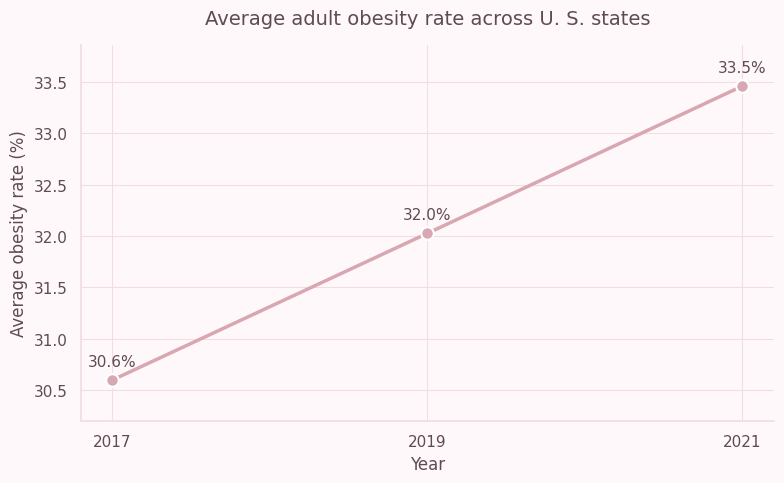

In [13]:
# Calculate the average obesity rate for each year
annual_obesity = model_data.groupby(
    "year",
    as_index=False
)["obesity_pct"].mean()


# Soft pink colors
soft_pink = "#D8A7B1"
soft_background = "#FFF8FA"
soft_grid = "#F1DDE2"
soft_text = "#5F4B52"


# Create the figure
fig, ax = plt.subplots(
    figsize=(8, 5),
    facecolor=soft_background
)

ax.set_facecolor(soft_background)


# Create the line chart
sns.lineplot(
    data=annual_obesity,
    x="year",
    y="obesity_pct",
    marker="o",
    markersize=9,
    linewidth=2.5,
    color=soft_pink,
    markerfacecolor=soft_pink,
    markeredgecolor="white",
    markeredgewidth=1.5,
    ax=ax
)


# Add the title and labels
ax.set_title(
    "Average adult obesity rate across U. S. states",
    color=soft_text,
    fontsize=14,
    pad=15
)

ax.set_xlabel(
    "Year",
    color=soft_text
)

ax.set_ylabel(
    "Average obesity rate (%)",
    color=soft_text
)

ax.set_xticks(
    [2017, 2019, 2021]
)


# Add space around the values
ax.set_ylim(
    annual_obesity["obesity_pct"].min() - 0.4,
    annual_obesity["obesity_pct"].max() + 0.4
)


# Add the values above the points
for _, row in annual_obesity.iterrows():

    ax.annotate(
        f'{row["obesity_pct"]:.1f}%',
        xy=(
            row["year"],
            row["obesity_pct"]
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        color=soft_text,
        fontsize=11
    )


# Make the grid softer
ax.grid(
    True,
    color=soft_grid,
    linewidth=0.8
)


# Remove the top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Make the other borders softer
ax.spines["left"].set_color(soft_grid)
ax.spines["bottom"].set_color(soft_grid)


# Change the tick colors
ax.tick_params(
    colors=soft_text
)


plt.tight_layout()
plt.show()

- The chart shows that the average adult obesity rate increased during the study period.

- The average rate was 30.6% in 2017, 32.0% in 2019, and 33.5% in 2021. This was an increase of about 2.86 percentage points from 2017 to 2021.

- The chart shows a steady upward trend across the three years. However, it does not explain why obesity rates increased.


### 3.4. Correlation table

In [14]:
# Select the three main variables
correlation_columns = [
    "obesity_pct",
    "no_leisure_activity_pct",
    "low_fruit_consumption_pct"
]

# Calculate the correlations
correlation_matrix = model_data[
    correlation_columns
].corr().round(3)

correlation_matrix

,obesity_pct,no_leisure_activity_pct,low_fruit_consumption_pct
obesity_pct,1.000,0.594,0.767
no_leisure_activity_pct,0.594,1.000,0.545
low_fruit_consumption_pct,0.767,0.545,1.000


Expected correlations:

- Obesity and physical inactivity: approximately 0.594.
- Obesity and low fruit consumption: approximately 0.767.
- Physical inactivity and low fruit consumption: approximately 0.545

### 3.5. Correlation heatmap

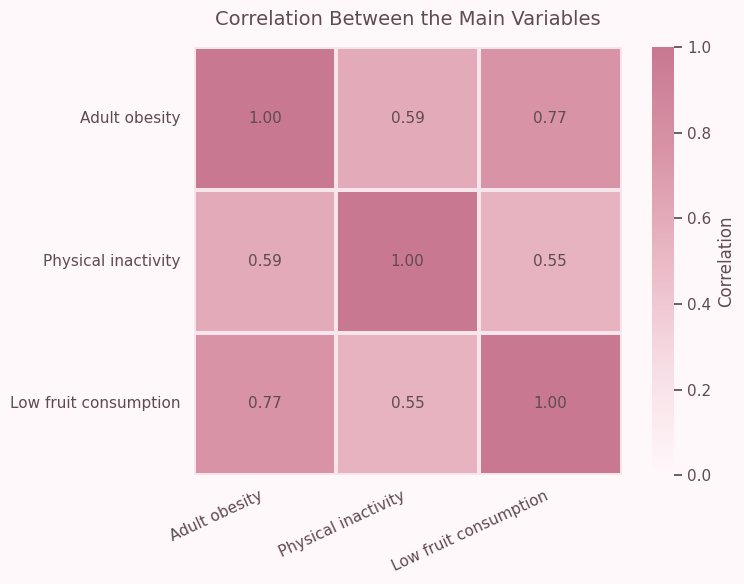

In [15]:
from matplotlib.colors import LinearSegmentedColormap


# Create easier names for the chart
variable_names = {
    "obesity_pct": "Adult obesity",
    "no_leisure_activity_pct": "Physical inactivity",
    "low_fruit_consumption_pct": "Low fruit consumption"
}

correlation_plot = correlation_matrix.rename(
    index=variable_names,
    columns=variable_names
)


# Soft pink colors
soft_background = "#FFF8FA"
soft_text = "#5F4B52"
soft_border = "#F6E5EA"

soft_pink_cmap = LinearSegmentedColormap.from_list(
    "soft_pink",
    [
        "#FFF8FA",
        "#F7DDE5",
        "#EAB9C6",
        "#D995A8",
        "#C87891"
    ]
)


# Create the figure
fig, ax = plt.subplots(
    figsize=(8, 6),
    facecolor=soft_background
)

ax.set_facecolor(soft_background)


# Create the correlation heatmap
heatmap = sns.heatmap(
    correlation_plot,
    annot=True,
    fmt=".2f",
    cmap=soft_pink_cmap,
    vmin=0,
    vmax=1,
    linewidths=1.5,
    linecolor=soft_border,
    square=True,
    annot_kws={
        "color": soft_text,
        "fontsize": 11
    },
    cbar_kws={
        "label": "Correlation"
    },
    ax=ax
)


# Add the title
ax.set_title(
    "Correlation Between the Main Variables",
    color=soft_text,
    fontsize=14,
    pad=16
)


# Format the variable labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=25,
    ha="right",
    color=soft_text
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    color=soft_text
)


# Format the color bar
color_bar = heatmap.collections[0].colorbar

color_bar.ax.yaxis.label.set_color(
    soft_text
)

color_bar.ax.tick_params(
    colors=soft_text
)


plt.tight_layout()
plt.show()

- The heatmap shows that the three variables are related.

- The strongest relationship was between obesity and low fruit consumption, with a correlation of 0.77. In states where more adults ate fruit less than once a day, the obesity rate was usually higher.

- Obesity and physical inactivity had a correlation of 0.59. Physical inactivity and low fruit consumption had a correlation of 0.55.

- These are positive relationships, but this does not mean that one variable directly causes another.



### 3.6. Relationship plots

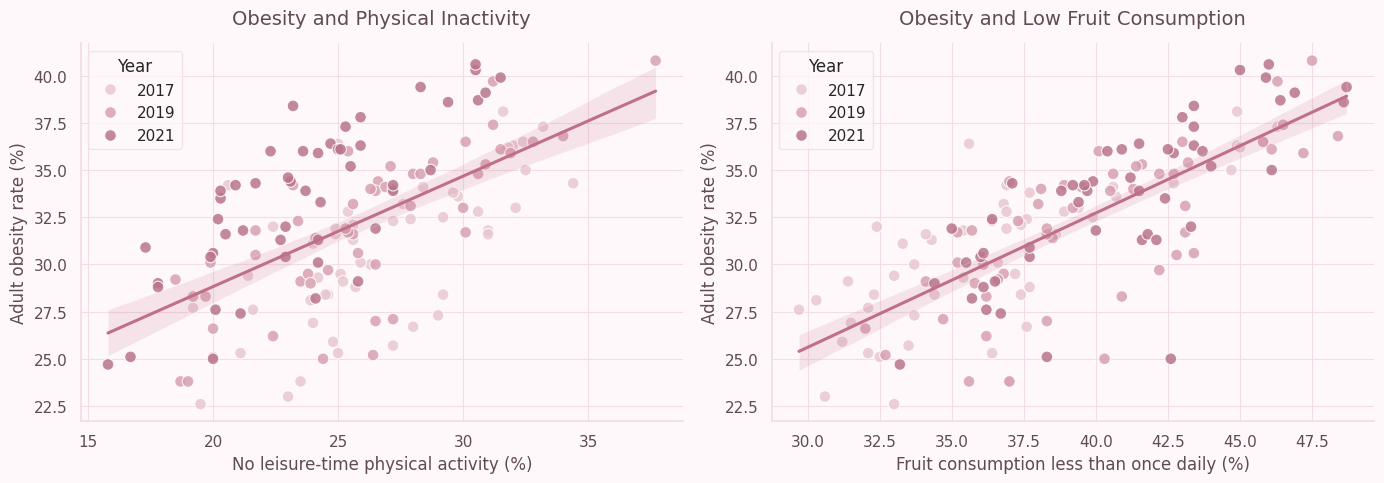

In [16]:
# Soft pink colors for each year
year_colors = {
    2017: "#E8C7D0",
    2019: "#D7A0B0",
    2021: "#B9748C"
}

soft_background = "#FFF8FA"
soft_grid = "#F1DDE2"
soft_text = "#5F4B52"
regression_rose = "#C06F89"


# Create the two charts
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    facecolor=soft_background
)


# -----------------------------------
# Obesity and physical inactivity
# -----------------------------------

sns.scatterplot(
    data=model_data,
    x="no_leisure_activity_pct",
    y="obesity_pct",
    hue="year",
    hue_order=[2017, 2019, 2021],
    palette=year_colors,
    s=70,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
    ax=axes[0]
)

sns.regplot(
    data=model_data,
    x="no_leisure_activity_pct",
    y="obesity_pct",
    scatter=False,
    color=regression_rose,
    line_kws={
        "linewidth": 2.2
    },
    ax=axes[0]
)

axes[0].set_title(
    "Obesity and Physical Inactivity",
    color=soft_text,
    fontsize=14,
    pad=14
)

axes[0].set_xlabel(
    "No leisure-time physical activity (%)",
    color=soft_text
)

axes[0].set_ylabel(
    "Adult obesity rate (%)",
    color=soft_text
)


# -----------------------------------
# Obesity and low fruit consumption
# -----------------------------------

sns.scatterplot(
    data=model_data,
    x="low_fruit_consumption_pct",
    y="obesity_pct",
    hue="year",
    hue_order=[2017, 2019, 2021],
    palette=year_colors,
    s=70,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
    ax=axes[1]
)

sns.regplot(
    data=model_data,
    x="low_fruit_consumption_pct",
    y="obesity_pct",
    scatter=False,
    color=regression_rose,
    line_kws={
        "linewidth": 2.2
    },
    ax=axes[1]
)

axes[1].set_title(
    "Obesity and Low Fruit Consumption",
    color=soft_text,
    fontsize=14,
    pad=14
)

axes[1].set_xlabel(
    "Fruit consumption less than once daily (%)",
    color=soft_text
)

axes[1].set_ylabel(
    "Adult obesity rate (%)",
    color=soft_text
)


# -----------------------------------
# Format both charts
# -----------------------------------

for ax in axes:

    ax.set_facecolor(
        soft_background
    )

    ax.grid(
        True,
        color=soft_grid,
        linewidth=0.8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color(
        soft_grid
    )

    ax.spines["bottom"].set_color(
        soft_grid
    )

    ax.tick_params(
        colors=soft_text
    )

    legend = ax.legend(
        title="Year",
        frameon=True
    )

    legend.get_frame().set_facecolor(
        soft_background
    )

    legend.get_frame().set_edgecolor(
        soft_grid
    )


plt.tight_layout()
plt.show()

- Both charts show a positive relationship with adult obesity.

- The first chart shows that states with more physical inactivity usually had higher obesity rates. However, the points are spread out, so the relationship is not perfect.

- The second chart shows a stronger relationship between low fruit consumption and obesity. States where more adults ate fruit less than once a day usually had higher obesity rates.

- The colors represent the three years. The results show clear patterns, but they do not prove that physical inactivity or low fruit consumption causes obesity.


## **4. Geographic and Demographic Analysis**

In this section, we compare obesity rates across U.S. states. We also explore the obesity estimates for different demographic groups.

The state analysis uses the total adult population. The demographic analysis includes groups based on income, age, race and ethnicity, education, and sex.



### 4.1. State obesity rates in 2021

In [17]:
# Select data from 2021
state_2021 = model_data[
    model_data["year"] == 2021
].copy()

# Sort the states from highest to lowest obesity rate
state_2021 = state_2021.sort_values(
    "obesity_pct",
    ascending=False
)

print("Number of states in 2021:", state_2021.shape[0])

state_2021.head(10)

Number of states in 2021: 50


,year,state_abbr,state,obesity_pct,no_leisure_activity_pct,low_fruit_consumption_pct
149,2021,WV,West Virginia,40.6,30.5,46.0
117,2021,KY,Kentucky,40.3,30.5,45.0
102,2021,AL,Alabama,39.9,31.5,45.9
136,2021,OK,Oklahoma,39.4,28.3,48.7
125,2021,MS,Mississippi,39.1,30.9,46.9
103,2021,AR,Arkansas,38.7,30.6,46.4
118,2021,LA,Louisiana,38.6,29.4,48.6
141,2021,SD,South Dakota,38.4,23.2,43.4
135,2021,OH,Ohio,37.8,25.9,43.0
124,2021,MO,Missouri,37.3,25.3,43.4


### 4.2. States with the highest obesity rates

In [18]:
# Select the ten states with the highest obesity rates
highest_10 = state_2021.head(10)

highest_10[
    [
        "state",
        "obesity_pct",
        "no_leisure_activity_pct",
        "low_fruit_consumption_pct"
    ]
]

,state,obesity_pct,no_leisure_activity_pct,low_fruit_consumption_pct
149,West Virginia,40.6,30.5,46.0
117,Kentucky,40.3,30.5,45.0
102,Alabama,39.9,31.5,45.9
136,Oklahoma,39.4,28.3,48.7
125,Mississippi,39.1,30.9,46.9
103,Arkansas,38.7,30.6,46.4
118,Louisiana,38.6,29.4,48.6
141,South Dakota,38.4,23.2,43.4
135,Ohio,37.8,25.9,43.0
124,Missouri,37.3,25.3,43.4


The first states should include:

- West Virginia: 40.6%.
- Kentucky: 40.3%.
- Alabama: 39.9%.
- Oklahoma: 39.4%.
- Mississippi: 39.1%.

### 4.3. Chart of the highest obesity rates

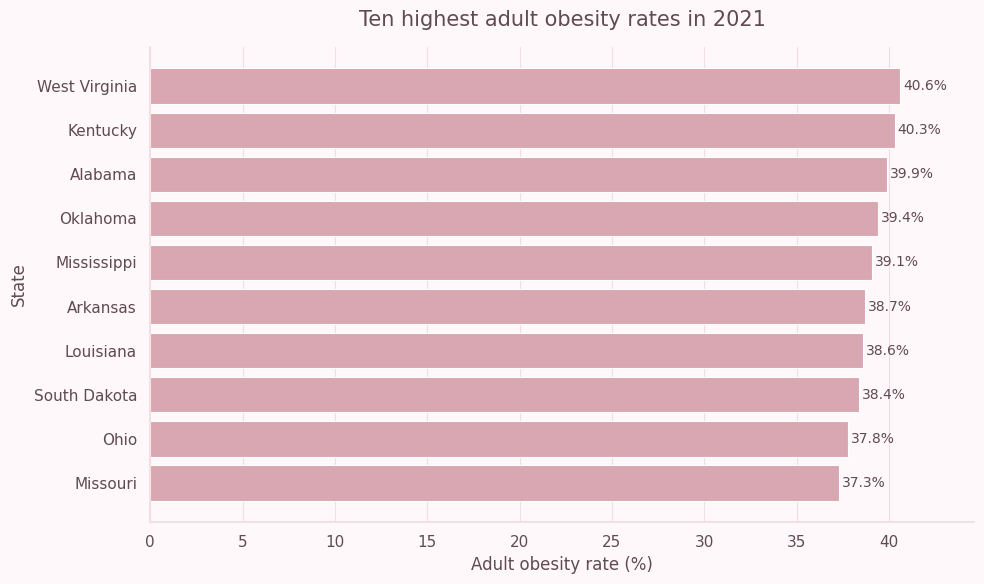

In [19]:
# Sort the values for a horizontal bar chart
highest_10_chart = highest_10.sort_values("obesity_pct")

# Soft pink colors
soft_pink = "#D8A7B1"
soft_background = "#FFF8FA"
soft_grid = "#F1DDE2"
soft_text = "#5F4B52"

# Create the chart
fig, ax = plt.subplots(figsize=(10, 6), facecolor=soft_background)
ax.set_facecolor(soft_background)

bars = ax.barh(
    highest_10_chart["state"],
    highest_10_chart["obesity_pct"],
    color=soft_pink,
    edgecolor="white",
    linewidth=0.8
)

# Titles and labels
ax.set_title(
    "Ten highest adult obesity rates in 2021",
    fontsize=15,
    color=soft_text,
    pad=15
)

ax.set_xlabel("Adult obesity rate (%)", color=soft_text)
ax.set_ylabel("State", color=soft_text)

# Add the values beside the bars
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        color=soft_text
    )

# Chart formatting
ax.set_xlim(
    0,
    highest_10_chart["obesity_pct"].max() + 4
)

ax.xaxis.grid(
    True,
    color=soft_grid,
    linewidth=0.8
)

ax.yaxis.grid(False)
ax.set_axisbelow(True)

ax.tick_params(colors=soft_text)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(soft_grid)
ax.spines["bottom"].set_color(soft_grid)

plt.tight_layout()
plt.show()

- The chart shows the ten states with the highest adult obesity rates in 2021. West Virginia had the highest rate at 40.6%, followed by Kentucky at 40.3% and Alabama at 39.9%.

- All ten states had obesity rates above 37%. The rates were close to each other. The difference between West Virginia and Missouri was only 3.3 percentage points.




### 4.4. Number of demographic observations

In [20]:
# Count the rows for each demographic category
stratification_counts = (
    demographic_data["stratification_category"]
    .value_counts()
    .reset_index()
)

stratification_counts.columns = [
    "demographic_category",
    "number_of_rows"
]

stratification_counts

,demographic_category,number_of_rows
0,Income,1056
1,Age (years),906
2,Race/Ethnicity,815
3,Education,604
4,Sex,302
5,Total,151


### 4.5. Obesity distribution by demographic category

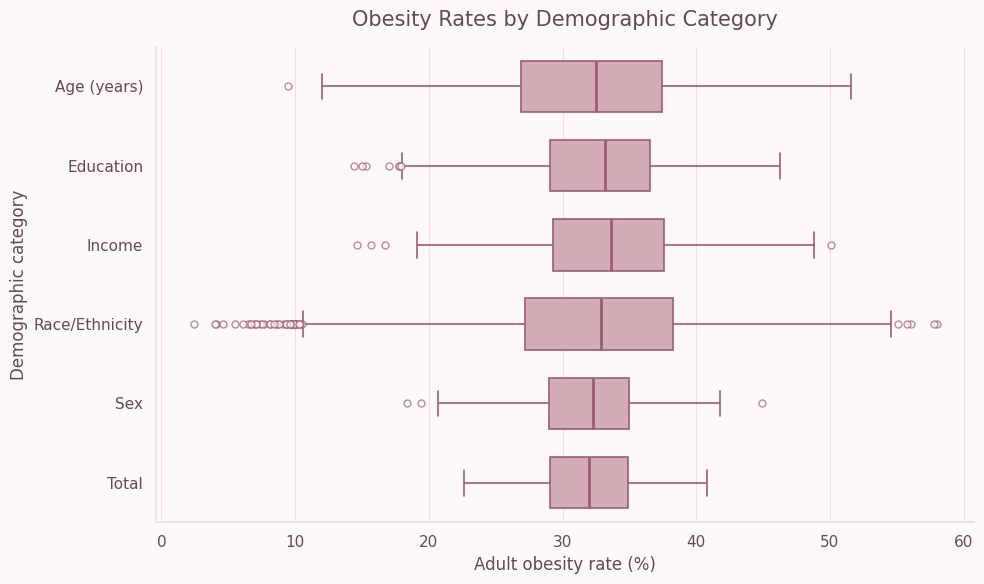

In [21]:
# Soft pink colors
soft_pink = "#D8A7B1"
dark_pink = "#9D5C73"
soft_background = "#FFF8FA"
soft_grid = "#F1DDE2"
soft_text = "#5F4B52"

# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 6), facecolor=soft_background)
ax.set_facecolor(soft_background)

sns.boxplot(
    data=demographic_data,
    x="obesity_pct",
    y="stratification_category",
    color=soft_pink,
    width=0.65,
    boxprops={
        "edgecolor": dark_pink,
        "linewidth": 1.2
    },
    medianprops={
        "color": dark_pink,
        "linewidth": 2
    },
    whiskerprops={
        "color": dark_pink,
        "linewidth": 1.2
    },
    capprops={
        "color": dark_pink,
        "linewidth": 1.2
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": soft_background,
        "markeredgecolor": dark_pink,
        "markersize": 5,
        "alpha": 0.7
    },
    ax=ax
)

# Titles and labels
ax.set_title(
    "Obesity Rates by Demographic Category",
    fontsize=15,
    color=soft_text,
    pad=15
)

ax.set_xlabel("Adult obesity rate (%)", color=soft_text)
ax.set_ylabel("Demographic category", color=soft_text)

# Chart formatting
ax.xaxis.grid(
    True,
    color=soft_grid,
    linewidth=0.8
)

ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(colors=soft_text)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(soft_grid)
ax.spines["bottom"].set_color(soft_grid)

plt.tight_layout()
plt.show()

- This chart compares obesity estimates across the demographic categories. The line inside each box shows the median obesity rate. The box shows the middle half of the estimates, and the dots represent values that are farther from the others.

- Most median obesity rates were between 32% and 34%. Race and ethnicity had the widest range and the largest number of unusual values. This suggests that obesity estimates varied more among the race and ethnicity groups. The sex and total categories had smaller ranges.

## **5. Build and Evaluate the Models**

The target variable is the adult obesity rate.

The two predictors are physical inactivity and low fruit consumption.

We compare four models:

- Mean baseline
- Linear Regression
- Random Forest
- Gradient Boosting

We use five-fold grouped cross-validation. All observations from the same state stay in the same group. This prevents a state from appearing in both the training and testing data during the same fold.


### 5.1. Import the modeling packages

In [22]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.model_selection import (
    GroupKFold,
    cross_val_predict
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 5.2. Define the target and predictors

In [23]:
# Predictor columns
feature_columns = [
    "no_leisure_activity_pct",
    "low_fruit_consumption_pct"
]

# Target column
target_column = "obesity_pct"

# Create X and y
X = model_data[feature_columns]
y = model_data[target_column]

# Use the state abbreviation as the group
groups = model_data["state_abbr"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of state groups:", groups.nunique())

X.head()

X shape: (151, 2)
y shape: (151,)
Number of state groups: 51


,no_leisure_activity_pct,low_fruit_consumption_pct
0,20.6,36.9
1,32.0,44.9
2,32.5,44.7
3,25.1,37.2
4,20.0,32.5


### 5.3. Create the models

In [24]:
# Create the models
models = {
    "Mean Baseline": DummyRegressor(
        strategy="mean"
    ),

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=4,
        random_state=42
    )
}

# Create five groups for cross-validation
group_cv = GroupKFold(n_splits=5)

### 5.4. Evaluate the models

In [25]:
# Store the predictions and results
model_predictions = {}
model_results = []

for model_name, model in models.items():

    # Create predictions using grouped cross-validation
    predictions = cross_val_predict(
        model,
        X,
        y,
        groups=groups,
        cv=group_cv
    )

    # Save the predictions
    model_predictions[model_name] = predictions

    # Calculate the evaluation metrics
    mae = mean_absolute_error(y, predictions)

    rmse = np.sqrt(
        mean_squared_error(y, predictions)
    )

    r2 = r2_score(y, predictions)

    # Save the results
    model_results.append(
        {
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        }
    )

# Create a results table
results_df = pd.DataFrame(model_results)

# Round the results
results_df[
    ["MAE", "RMSE", "R2"]
] = results_df[
    ["MAE", "RMSE", "R2"]
].round(3)

# Sort by RMSE
results_df = results_df.sort_values(
    "RMSE"
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,1.997,2.537,0.619
1,Gradient Boosting,2.149,2.691,0.571
2,Random Forest,2.147,2.747,0.554
3,Mean Baseline,3.453,4.216,-0.052


- Linear Regression had the best overall results. It had the lowest RMSE and the highest R² score.

- Its MAE was about 2.00 percentage points. This means that its predictions were different from the real obesity rates by about 2.00 percentage points on average.

- Its R² score was 0.619. This means that the model explained about 61.9% of the variation in adult obesity rates.

- The three regression models performed better than the mean baseline.

## **6. Compare the Model Results**

We compare the models using three measures:

- **MAE** shows the average prediction error.
- **RMSE** gives more importance to large prediction errors.
- **R²** shows how much of the variation is explained by the model.

Lower MAE and RMSE values are better. A higher R² value is better.



In [26]:
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,1.997,2.537,0.619
1,Gradient Boosting,2.149,2.691,0.571
2,Random Forest,2.147,2.747,0.554
3,Mean Baseline,3.453,4.216,-0.052


### 6.1. Compare MAE and R²

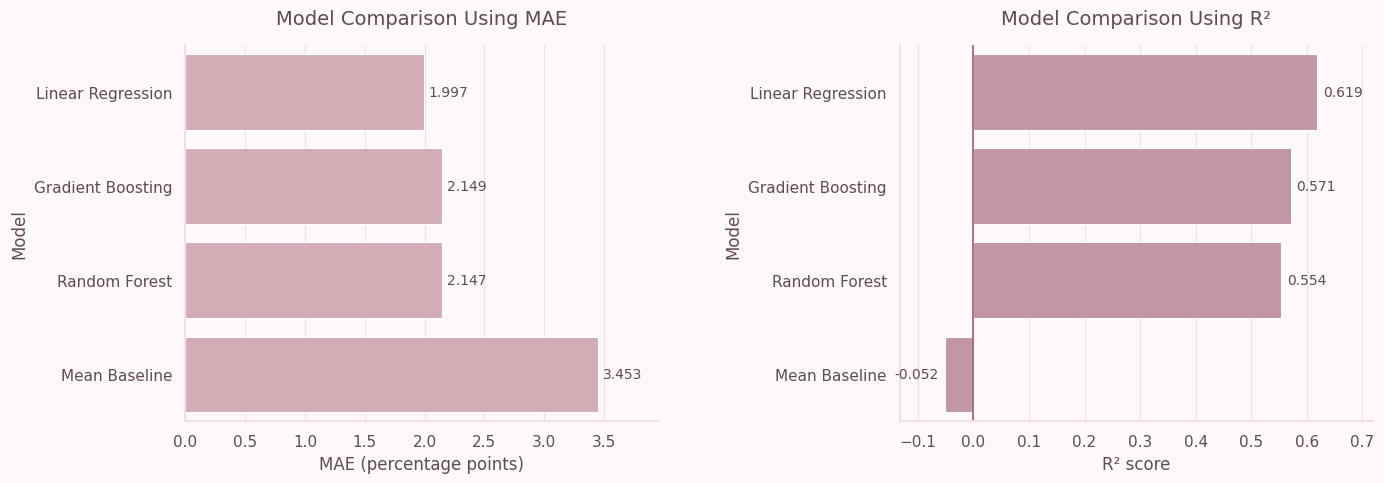

In [27]:
# Soft pink colors
soft_pink = "#D8A7B1"
medium_pink = "#C98FA1"
dark_pink = "#9D5C73"
soft_background = "#FFF8FA"
soft_grid = "#F1DDE2"
soft_text = "#5F4B52"

# Keep the models in their current order
model_order = results_df["Model"].tolist()

# Create the charts
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    facecolor=soft_background
)

# MAE comparison
sns.barplot(
    data=results_df,
    x="MAE",
    y="Model",
    order=model_order,
    color=soft_pink,
    edgecolor="white",
    linewidth=0.8,
    ax=axes[0]
)

axes[0].set_title(
    "Model Comparison Using MAE",
    fontsize=14,
    color=soft_text,
    pad=15
)

axes[0].set_xlabel(
    "MAE (percentage points)",
    color=soft_text
)

axes[0].set_ylabel("Model", color=soft_text)

# Add the MAE values
for bar in axes[0].patches:
    value = bar.get_width()

    axes[0].text(
        value + 0.04,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=10,
        color=soft_text
    )

axes[0].set_xlim(
    0,
    results_df["MAE"].max() + 0.5
)

# R² comparison
sns.barplot(
    data=results_df,
    x="R2",
    y="Model",
    order=model_order,
    color=medium_pink,
    edgecolor="white",
    linewidth=0.8,
    ax=axes[1]
)

axes[1].axvline(
    0,
    color=dark_pink,
    linewidth=1.2
)

axes[1].set_title(
    "Model Comparison Using R²",
    fontsize=14,
    color=soft_text,
    pad=15
)

axes[1].set_xlabel("R² score", color=soft_text)
axes[1].set_ylabel("Model", color=soft_text)

# Add the R² values
for bar in axes[1].patches:
    value = bar.get_width()

    if value >= 0:
        label_position = value + 0.01
        alignment = "left"
    else:
        label_position = value - 0.01
        alignment = "right"

    axes[1].text(
        label_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha=alignment,
        fontsize=10,
        color=soft_text
    )

# Add space for the negative baseline value and labels
axes[1].set_xlim(
    min(-0.12, results_df["R2"].min() - 0.08),
    results_df["R2"].max() + 0.10
)

# Format both charts
for ax in axes:
    ax.set_facecolor(soft_background)
    ax.xaxis.grid(True, color=soft_grid, linewidth=0.8)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(colors=soft_text)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(soft_grid)
    ax.spines["bottom"].set_color(soft_grid)

plt.tight_layout(w_pad=4)
plt.show()

- These charts compare the performance of the regression models. A lower MAE is better because it means the predictions had less error. A higher R² score is also better because it means the model explained more of the differences in obesity rates.

- Linear Regression had the best results. Its MAE was 1.997, which means that its predictions were off by about 2 percentage points on average. It also had the highest R² score at 0.619.

- Gradient Boosting and Random Forest performed well, but their results were slightly lower. The Mean Baseline had the highest MAE and a negative R² score. This shows that all three trained models performed better than the baseline.

- Based on both measures, Linear Regression was selected as the best model.


### 6.2. Actual and predicted values

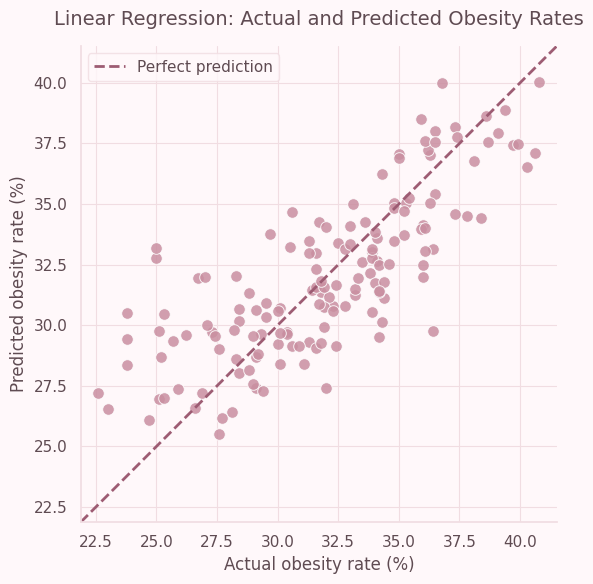

In [28]:
# Get the Linear Regression predictions
linear_predictions = model_predictions[
    "Linear Regression"
]

# Soft pink colors
soft_pink = "#C98FA1"
dark_pink = "#9D5C73"
soft_background = "#FFF8FA"
soft_grid = "#F1DDE2"
soft_text = "#5F4B52"

# Create the chart
fig, ax = plt.subplots(
    figsize=(7, 6),
    facecolor=soft_background
)

ax.set_facecolor(soft_background)

sns.scatterplot(
    x=y,
    y=linear_predictions,
    color=soft_pink,
    edgecolor="white",
    linewidth=0.7,
    s=70,
    alpha=0.85,
    ax=ax
)

# Find the minimum and maximum values
minimum_value = min(
    y.min(),
    np.min(linear_predictions)
)

maximum_value = max(
    y.max(),
    np.max(linear_predictions)
)

# Add a small amount of space around the data
padding = (maximum_value - minimum_value) * 0.04

axis_minimum = minimum_value - padding
axis_maximum = maximum_value + padding

# Create the perfect prediction line
ax.plot(
    [axis_minimum, axis_maximum],
    [axis_minimum, axis_maximum],
    color=dark_pink,
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

# Use the same range on both axes
ax.set_xlim(axis_minimum, axis_maximum)
ax.set_ylim(axis_minimum, axis_maximum)
ax.set_aspect("equal", adjustable="box")

# Titles and labels
ax.set_title(
    "Linear Regression: Actual and Predicted Obesity Rates",
    fontsize=14,
    color=soft_text,
    pad=15
)

ax.set_xlabel("Actual obesity rate (%)", color=soft_text)
ax.set_ylabel("Predicted obesity rate (%)", color=soft_text)

# Chart formatting
ax.grid(
    True,
    color=soft_grid,
    linewidth=0.8
)

ax.set_axisbelow(True)
ax.tick_params(colors=soft_text)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(soft_grid)
ax.spines["bottom"].set_color(soft_grid)

legend = ax.legend(
    facecolor=soft_background,
    edgecolor=soft_grid
)

for text in legend.get_texts():
    text.set_color(soft_text)

plt.tight_layout()
plt.show()

- This chart compares the actual obesity rates with the rates predicted by the Linear Regression model. Each point represents one state and year observation.

- The dashed line represents a perfect prediction. Points close to this line show that the predicted rate was close to the actual rate. Points above the line are predictions that were too high, while points below the line are predictions that were too low.

- Many points are close to the line, showing that the model identified the general pattern in the data. However, some points are farther away. The model also appears to predict some low obesity rates too high and some high obesity rates too low.

## **7. Interpret the Linear Regression Model**

Linear Regression was selected as the final model because it had the best overall results.

The model coefficients show how each predictor is related to the predicted adult obesity rate. The model is fitted using all 151 observations for the final interpretation.


### 7.1. Fit the final model

In [29]:
# Create the final Linear Regression model
final_model = LinearRegression()

# Fit the model using all observations
final_model.fit(X, y)

print(
    "Model intercept:",
    round(final_model.intercept_, 3)
)

print(
    "Model coefficients:",
    final_model.coef_.round(3)
)

Model intercept: 2.906
Model coefficients: [0.246 0.586]


### 7.2. Create a coefficient table

In [30]:
# Create a table with the feature names and coefficients
coefficient_table = pd.DataFrame(
    {
        "Predictor": [
            "No leisure-time physical activity",
            "Fruit consumption less than once daily"
        ],
        "Coefficient": final_model.coef_
    }
)

# Round the coefficients
coefficient_table["Coefficient"] = (
    coefficient_table["Coefficient"].round(3)
)

coefficient_table

,Predictor,Coefficient
0,No leisure-time physical activity,0.246
1,Fruit consumption less than once daily,0.586


### 7.3. Show the model equation

In [31]:
inactivity_coefficient = final_model.coef_[0]
fruit_coefficient = final_model.coef_[1]
intercept = final_model.intercept_

print("Linear Regression equation:")
print(
    f"Obesity rate = {intercept:.3f} "
    f"+ ({inactivity_coefficient:.3f} × physical inactivity) "
    f"+ ({fruit_coefficient:.3f} × low fruit consumption)"
)

Linear Regression equation:
Obesity rate = 2.906 + (0.246 × physical inactivity) + (0.586 × low fruit consumption)


### 7.4. Visualize the coefficients

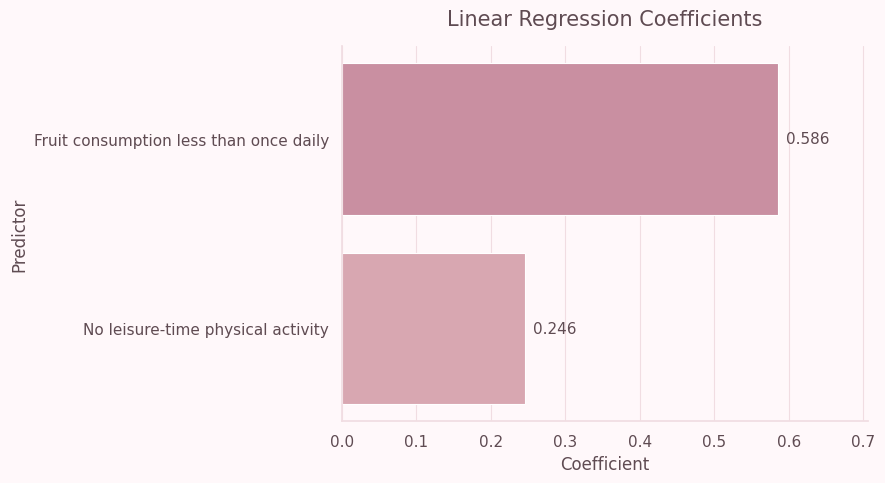

In [32]:
# Soft pink colors
soft_pink = "#D8A7B1"
medium_pink = "#C98FA1"
dark_pink = "#9D5C73"
soft_background = "#FFF8FA"
soft_grid = "#F1DDE2"
soft_text = "#5F4B52"

# Create the chart
fig, ax = plt.subplots(
    figsize=(9, 5),
    facecolor=soft_background
)

ax.set_facecolor(soft_background)

bars = ax.barh(
    coefficient_table["Predictor"],
    coefficient_table["Coefficient"],
    color=[soft_pink, medium_pink],
    edgecolor="white",
    linewidth=0.8
)

# Title and labels
ax.set_title(
    "Linear Regression Coefficients",
    fontsize=15,
    color=soft_text,
    pad=15
)

ax.set_xlabel("Coefficient", color=soft_text)
ax.set_ylabel("Predictor", color=soft_text)

# Add the coefficient values
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=11,
        color=soft_text
    )

# Add space for the value labels
ax.set_xlim(
    0,
    coefficient_table["Coefficient"].max() + 0.12
)

# Chart formatting
ax.xaxis.grid(
    True,
    color=soft_grid,
    linewidth=0.8
)

ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(colors=soft_text)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(soft_grid)
ax.spines["bottom"].set_color(soft_grid)

plt.tight_layout()
plt.show()

- Physical inactivity had a coefficient of 0.246. This means that when physical inactivity increased by one percentage point, the predicted obesity rate increased by 0.246 percentage points.
- Low fruit consumption had a coefficient of 0.586. This means that when low fruit consumption increased by one percentage point, the predicted obesity rate increased by 0.586 percentage points.

- Low fruit consumption had the larger coefficient, so it had a stronger relationship with the predicted obesity rate.

- These results only show relationships between state level data. They do not prove that physical inactivity or low fruit consumption causes obesity.


## **8. Conclusions and Limitations**

### 8.1. Conclusions

This project studied the relationship between adult obesity, physical inactivity, and low fruit consumption across U.S. states.

The main findings were:

1. The average state obesity rate increased from 30.6% in 2017 to 33.5% in 2021.

2. Physical inactivity had a positive relationship with adult obesity. States with higher physical inactivity usually had higher obesity rates.

3. Low fruit consumption also had a positive relationship with adult obesity. It had a stronger relationship with obesity than physical inactivity.

4. Linear Regression had the best model results. It had an MAE of about 2.00 percentage points and an R² score of 0.619.

5. The model explained about 61.9% of the differences in adult obesity rates.

### 8.2. Limitations

This project has several limitations:

- The data comes from self reported survey answers. Some answers may not be completely accurate.

- The data contains state and demographic group percentages. It does not contain information about individual people.

- The three selected variables were available together only for 2017, 2019, and 2021.

- The model only used two predictors. Other factors, such as income, healthcare access, education, and the food environment, may also be related to obesity.

- The results show relationships between the variables. They do not prove that physical inactivity or low fruit consumption causes obesity.

### Final Statement

This project shows that physical inactivity and low fruit consumption are related to adult obesity rates across U.S. states. The results may help identify important public health patterns, but more data and research are needed to better understand these relationships.


In [33]:
from pathlib import Path

# Project folder in Google Drive
PROJECT_DIR = Path(
    "/content/drive/MyDrive/cdc_obesity_portfolio"
)

DATA_DIR = PROJECT_DIR / "data"

# Create the folders
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save the prepared datasets
model_data.to_csv(
    DATA_DIR / "obesity_lifestyle_model_data.csv",
    index=False
)

demographic_data.to_csv(
    DATA_DIR / "obesity_lifestyle_demographic_data.csv",
    index=False
)

print("Project folder created:", PROJECT_DIR)
print("\nFiles saved:")

for file in PROJECT_DIR.rglob("*"):
    if file.is_file():
        print("-", file.relative_to(PROJECT_DIR))

Project folder created: /content/drive/MyDrive/cdc_obesity_portfolio

Files saved:
- obesity_lifestyle_analysis.ipynb.ipynb
- data/obesity_lifestyle_model_data.csv
- data/obesity_lifestyle_demographic_data.csv


In [34]:
%%writefile /content/drive/MyDrive/cdc_obesity_portfolio/README.md
# Adult Obesity and Lifestyle Factors in the United States

## Project Overview

This project studies the relationship between adult obesity, physical inactivity, and low fruit consumption across U.S. states and demographic groups.

The analysis uses aggregated estimates from the CDC Behavioral Risk Factor Surveillance System for 2017, 2019, and 2021.

## Research Question

How are physical inactivity and low fruit consumption associated with adult obesity prevalence across U.S. states and demographic groups?

## Variables

**Target variable**

- `obesity_pct`: Adult obesity prevalence.

**Predictors**

- `no_leisure_activity_pct`: Adults who reported no leisure-time physical activity.
- `low_fruit_consumption_pct`: Adults who consumed fruit less than once daily.

All variables are percentages.

## Data Source

The data comes from the CDC Nutrition, Physical Activity, and Obesity dataset:

[CDC Open Data Page](https://data.cdc.gov/Nutrition-Physical-Activity-and-Obesity/Nutrition-Physical-Activity-and-Obesity-Behavioral/hn4x-zwk7)

The original CSV contains 110,880 rows. It remains unchanged.

The preparation process created:

- 151 state-year rows for modeling.
- 3,834 state-year-demographic rows for subgroup exploration.
- Data from 50 states and Washington, D.C.
- Estimates from 2017, 2019, and 2021.

## Project Steps

1. Loaded and reviewed the original CDC data.
2. Selected the three main health questions.
3. Reshaped the questions into separate columns.
4. Created state-level and demographic datasets.
5. Explored trends, correlations, and demographic differences.
6. Compared regression models using grouped cross-validation.
7. Interpreted the best model and its coefficients.
8. Created an interactive dashboard.

## Exploratory Findings

- The average state obesity rate increased from 30.6% in 2017 to 33.5% in 2021.
- Physical inactivity had a positive correlation of 0.59 with obesity.
- Low fruit consumption had a positive correlation of 0.77 with obesity.
- West Virginia had the highest state obesity rate in 2021 at 40.6%.
- Obesity estimates varied across demographic categories.

## Model Comparison

The following models were compared:

- Linear Regression
- Gradient Boosting
- Random Forest
- Mean Baseline

Grouped cross-validation was used to keep observations from the same state together.

| Model | MAE | R² |
|---|---:|---:|
| Linear Regression | 1.997 | 0.619 |
| Gradient Boosting | 2.149 | 0.571 |
| Random Forest | 2.147 | 0.554 |
| Mean Baseline | 3.453 | -0.052 |

Linear Regression had the lowest MAE and the highest R² score. Therefore, it was selected as the final model.

## Linear Regression Results

The coefficient for physical inactivity was **0.246**.

A one-percentage-point increase in physical inactivity was associated with a 0.246-percentage-point increase in predicted obesity, while low fruit consumption remained the same.

The coefficient for low fruit consumption was **0.586**.

A one-percentage-point increase in low fruit consumption was associated with a 0.586-percentage-point increase in predicted obesity, while physical inactivity remained the same.

Low fruit consumption had the larger coefficient in this model.

## Important Limitation

This project uses aggregated survey estimates. The results show associations between variables, but they do not prove causation.

The analysis does not show that physical inactivity or low fruit consumption directly causes obesity.

## Project Structure

```text
cdc_obesity_portfolio/
├── README.md
├── obesity_lifestyle_analysis.ipynb
├── prepare_data.py
├── requirements.txt
├── data/
│   ├── obesity_lifestyle_model_data.csv
│   └── obesity_lifestyle_demographic_data.csv
└── dashboard/
    └── app.py
```

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Plotly
- Streamlit
- Google Colab

## Author

Janeth Garcia Rodriguez

Writing /content/drive/MyDrive/cdc_obesity_portfolio/README.md


In [35]:
%%writefile /content/drive/MyDrive/cdc_obesity_portfolio/requirements.txt
pandas
numpy
matplotlib
seaborn
scikit-learn
plotly
streamlit

Writing /content/drive/MyDrive/cdc_obesity_portfolio/requirements.txt


In [36]:
%%writefile /content/drive/MyDrive/cdc_obesity_portfolio/prepare_data.py
import argparse
from pathlib import Path

import pandas as pd


YEARS = [2017, 2019, 2021]

STATE_ABBREVIATIONS = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE",
    "FL", "GA", "HI", "ID", "IL", "IN", "IA", "KS",
    "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS",
    "MO", "MT", "NE", "NV", "NH", "NJ", "NM", "NY",
    "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV",
    "WI", "WY", "DC"
]

QUESTION_TO_COLUMN = {
    "Percent of adults aged 18 years and older who have obesity":
        "obesity_pct",

    "Percent of adults who engage in no leisure-time physical activity":
        "no_leisure_activity_pct",

    "Percent of adults who report consuming fruit less than one time daily":
        "low_fruit_consumption_pct"
}


def create_wide_table(data, index_columns):
    """Reshape the three selected questions into columns."""

    wide_data = (
        data.pivot_table(
            index=index_columns,
            columns="metric",
            values="Data_Value",
            aggfunc="first"
        )
        .dropna(
            subset=list(QUESTION_TO_COLUMN.values())
        )
        .reset_index()
        .rename_axis(None, axis=1)
    )

    return wide_data


def prepare_data(input_file, output_directory):
    """Create the model and demographic datasets."""

    input_file = Path(input_file)
    output_directory = Path(output_directory)

    if not input_file.exists():
        raise FileNotFoundError(
            f"Original CSV was not found: {input_file}"
        )

    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    # Load the original CDC CSV
    df = pd.read_csv(
        input_file,
        low_memory=False
    )

    required_columns = {
        "YearStart",
        "LocationAbbr",
        "LocationDesc",
        "Question",
        "Data_Value",
        "StratificationCategory1",
        "Stratification1"
    }

    missing_columns = required_columns.difference(
        df.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing columns: {sorted(missing_columns)}"
        )

    # Select the years, states, and questions
    selected_data = df[
        df["YearStart"].isin(YEARS)
        & df["LocationAbbr"].isin(STATE_ABBREVIATIONS)
        & df["Question"].isin(QUESTION_TO_COLUMN)
    ].copy()

    # Create shorter variable names
    selected_data["metric"] = selected_data[
        "Question"
    ].map(QUESTION_TO_COLUMN)

    # Convert the estimates to numbers
    selected_data["Data_Value"] = pd.to_numeric(
        selected_data["Data_Value"],
        errors="coerce"
    )

    # Create the state-year modeling data
    total_data = selected_data[
        selected_data["StratificationCategory1"] == "Total"
    ].copy()

    model_data = create_wide_table(
        total_data,
        [
            "LocationDesc",
            "LocationAbbr",
            "YearStart"
        ]
    )

    model_data = model_data.rename(
        columns={
            "LocationDesc": "state",
            "LocationAbbr": "state_abbr",
            "YearStart": "year"
        }
    )

    model_data = model_data[
        [
            "state",
            "state_abbr",
            "year",
            "obesity_pct",
            "no_leisure_activity_pct",
            "low_fruit_consumption_pct"
        ]
    ].sort_values(
        ["year", "state"]
    ).reset_index(drop=True)

    # Create the demographic dataset
    demographic_data = create_wide_table(
        selected_data,
        [
            "LocationDesc",
            "LocationAbbr",
            "YearStart",
            "StratificationCategory1",
            "Stratification1"
        ]
    )

    demographic_data = demographic_data.rename(
        columns={
            "LocationDesc": "state",
            "LocationAbbr": "state_abbr",
            "YearStart": "year",
            "StratificationCategory1":
                "stratification_category",
            "Stratification1": "stratification"
        }
    )

    demographic_data = demographic_data[
        [
            "state",
            "state_abbr",
            "year",
            "stratification_category",
            "stratification",
            "obesity_pct",
            "no_leisure_activity_pct",
            "low_fruit_consumption_pct"
        ]
    ].sort_values(
        [
            "year",
            "state",
            "stratification_category",
            "stratification"
        ]
    ).reset_index(drop=True)

    # Save the prepared files
    model_output = (
        output_directory
        / "obesity_lifestyle_model_data.csv"
    )

    demographic_output = (
        output_directory
        / "obesity_lifestyle_demographic_data.csv"
    )

    model_data.to_csv(
        model_output,
        index=False
    )

    demographic_data.to_csv(
        demographic_output,
        index=False
    )

    print("Data preparation completed.")
    print("Model data shape:", model_data.shape)
    print(
        "Demographic data shape:",
        demographic_data.shape
    )
    print("Model data saved to:", model_output)
    print(
        "Demographic data saved to:",
        demographic_output
    )


if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        description="Prepare the CDC obesity project data."
    )

    parser.add_argument(
        "--input",
        required=True,
        help="Path to the original CDC CSV file."
    )

    parser.add_argument(
        "--output-dir",
        default="data",
        help="Folder for the prepared CSV files."
    )

    arguments = parser.parse_args()

    prepare_data(
        arguments.input,
        arguments.output_dir
    )

Writing /content/drive/MyDrive/cdc_obesity_portfolio/prepare_data.py


In [38]:
%%writefile /content/drive/MyDrive/cdc_obesity_portfolio/app.py
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st


# Page settings
st.set_page_config(
    page_title="U.S. Adult Obesity Dashboard",
    page_icon="📊",
    layout="wide"
)


# Soft pink colors
SOFT_PINK = "#D8A7B1"
MEDIUM_PINK = "#C98FA1"
DARK_PINK = "#9D5C73"
BACKGROUND = "#FFF8FA"
GRID_COLOR = "#F1DDE2"
TEXT_COLOR = "#5F4B52"

PINK_SCALE = [
    "#FFF8FA",
    "#F3DCE2",
    "#D8A7B1",
    "#C47F95",
    "#9D5C73"
]


# Custom page style
st.markdown(
    """
    <style>
    .stApp {
        background-color: #FFF8FA;
    }

    h1, h2, h3 {
        color: #5F4B52;
    }

    [data-testid="stMetric"] {
        background-color: #FFFFFF;
        border: 1px solid #F1DDE2;
        border-radius: 12px;
        padding: 15px;
    }
    </style>
    """,
    unsafe_allow_html=True
)


# File paths
BASE_DIR = Path(__file__).resolve().parent
DATA_DIR = BASE_DIR / "data"

MODEL_FILE = (
    DATA_DIR
    / "obesity_lifestyle_model_data.csv"
)

DEMOGRAPHIC_FILE = (
    DATA_DIR
    / "obesity_lifestyle_demographic_data.csv"
)


@st.cache_data
def load_data():
    model = pd.read_csv(MODEL_FILE)
    demographic = pd.read_csv(DEMOGRAPHIC_FILE)

    model["year"] = model["year"].astype(int)
    demographic["year"] = demographic["year"].astype(int)

    return model, demographic


try:
    model_data, demographic_data = load_data()

except FileNotFoundError:
    st.error(
        "The prepared data files were not found. "
        "Make sure the two CSV files are inside the data folder."
    )
    st.stop()


# Title and description
st.title("U.S. Adult Obesity and Lifestyle Dashboard")

st.write(
    "Explore adult obesity, physical inactivity, and low fruit "
    "consumption across U.S. states. The data comes from CDC "
    "BRFSS estimates for 2017, 2019, and 2021."
)


# Sidebar filters
st.sidebar.header("Filters")

available_years = sorted(
    model_data["year"].unique().tolist()
)

selected_year = st.sidebar.selectbox(
    "Year",
    available_years,
    index=len(available_years) - 1
)

available_states = sorted(
    model_data["state"].unique().tolist()
)

selected_states = st.sidebar.multiselect(
    "States",
    available_states,
    placeholder="Leave empty to show all states"
)


# Apply filters
filtered_model = model_data[
    model_data["year"] == selected_year
].copy()

filtered_demographic = demographic_data[
    demographic_data["year"] == selected_year
].copy()

if selected_states:
    filtered_model = filtered_model[
        filtered_model["state"].isin(selected_states)
    ]

    filtered_demographic = filtered_demographic[
        filtered_demographic["state"].isin(selected_states)
    ]


if filtered_model.empty:
    st.warning("No data is available for these filters.")
    st.stop()


# Summary metrics
metric_1, metric_2, metric_3 = st.columns(3)

metric_1.metric(
    "Average obesity rate",
    f"{filtered_model['obesity_pct'].mean():.1f}%"
)

metric_2.metric(
    "Average physical inactivity",
    f"{filtered_model['no_leisure_activity_pct'].mean():.1f}%"
)

metric_3.metric(
    "Average low fruit consumption",
    f"{filtered_model['low_fruit_consumption_pct'].mean():.1f}%"
)


# Map
st.subheader(f"Adult Obesity Rates in {selected_year}")

map_figure = px.choropleth(
    filtered_model,
    locations="state_abbr",
    locationmode="USA-states",
    scope="usa",
    color="obesity_pct",
    hover_name="state",
    hover_data={
        "state_abbr": False,
        "obesity_pct": ":.1f",
        "no_leisure_activity_pct": ":.1f",
        "low_fruit_consumption_pct": ":.1f"
    },
    color_continuous_scale=PINK_SCALE,
    labels={
        "obesity_pct": "Obesity (%)",
        "no_leisure_activity_pct": "Physical inactivity (%)",
        "low_fruit_consumption_pct": "Low fruit consumption (%)"
    }
)

map_figure.update_layout(
    paper_bgcolor=BACKGROUND,
    plot_bgcolor=BACKGROUND,
    font_color=TEXT_COLOR,
    margin=dict(l=0, r=0, t=10, b=0)
)

st.plotly_chart(
    map_figure,
    use_container_width=True
)


# Function for scatterplots
def create_scatterplot(data, predictor, x_label, title):
    figure = px.scatter(
        data,
        x=predictor,
        y="obesity_pct",
        hover_name="state",
        labels={
            predictor: x_label,
            "obesity_pct": "Adult obesity rate (%)"
        },
        title=title
    )

    figure.update_traces(
        marker={
            "color": MEDIUM_PINK,
            "size": 10,
            "opacity": 0.85,
            "line": {
                "color": "white",
                "width": 1
            }
        }
    )

    clean_data = data[
        [predictor, "obesity_pct"]
    ].dropna()

    if (
        len(clean_data) >= 2
        and clean_data[predictor].nunique() > 1
    ):
        slope, intercept = np.polyfit(
            clean_data[predictor],
            clean_data["obesity_pct"],
            1
        )

        line_x = np.linspace(
            clean_data[predictor].min(),
            clean_data[predictor].max(),
            100
        )

        line_y = slope * line_x + intercept

        figure.add_trace(
            go.Scatter(
                x=line_x,
                y=line_y,
                mode="lines",
                name="Trend line",
                line={
                    "color": DARK_PINK,
                    "width": 2
                }
            )
        )

    figure.update_layout(
        paper_bgcolor=BACKGROUND,
        plot_bgcolor=BACKGROUND,
        font_color=TEXT_COLOR,
        legend_title_text="",
        xaxis_gridcolor=GRID_COLOR,
        yaxis_gridcolor=GRID_COLOR
    )

    return figure


# Scatterplots
st.subheader("Lifestyle Factors and Obesity")

chart_1, chart_2 = st.columns(2)

physical_activity_chart = create_scatterplot(
    filtered_model,
    "no_leisure_activity_pct",
    "No leisure-time physical activity (%)",
    "Obesity and Physical Inactivity"
)

fruit_chart = create_scatterplot(
    filtered_model,
    "low_fruit_consumption_pct",
    "Fruit consumption less than once daily (%)",
    "Obesity and Low Fruit Consumption"
)

chart_1.plotly_chart(
    physical_activity_chart,
    use_container_width=True
)

chart_2.plotly_chart(
    fruit_chart,
    use_container_width=True
)


# Demographic exploration
st.subheader("Demographic Exploration")

demographic_categories = sorted(
    filtered_demographic[
        "stratification_category"
    ].dropna().unique().tolist()
)

selected_category = st.selectbox(
    "Demographic category",
    demographic_categories
)

category_data = filtered_demographic[
    filtered_demographic[
        "stratification_category"
    ] == selected_category
].copy()

box_figure = px.box(
    category_data,
    x="obesity_pct",
    y="stratification",
    points="outliers",
    labels={
        "obesity_pct": "Adult obesity rate (%)",
        "stratification": selected_category
    },
    title=f"Obesity Rates by {selected_category}"
)

box_figure.update_traces(
    fillcolor=SOFT_PINK,
    line_color=DARK_PINK,
    marker_color=MEDIUM_PINK
)

box_figure.update_layout(
    paper_bgcolor=BACKGROUND,
    plot_bgcolor=BACKGROUND,
    font_color=TEXT_COLOR,
    xaxis_gridcolor=GRID_COLOR,
    yaxis_gridcolor=GRID_COLOR,
    showlegend=False
)

st.plotly_chart(
    box_figure,
    use_container_width=True
)


# Data table
st.subheader("Filtered State Data")

display_data = filtered_model[
    [
        "state",
        "year",
        "obesity_pct",
        "no_leisure_activity_pct",
        "low_fruit_consumption_pct"
    ]
].sort_values(
    "obesity_pct",
    ascending=False
).round(1)

st.dataframe(
    display_data,
    use_container_width=True,
    hide_index=True
)


# Limitation
st.info(
    "These results show associations between aggregated "
    "state-level estimates. They do not prove causation."
)

Writing /content/drive/MyDrive/cdc_obesity_portfolio/app.py


In [40]:
from pathlib import Path

readme_path = Path(
    "/content/drive/MyDrive/cdc_obesity_portfolio/README.md"
)

readme_text = readme_path.read_text(
    encoding="utf-8"
)

# Correct the location of app.py
readme_text = readme_text.replace(
    "└── dashboard/\n    └── app.py",
    "└── app.py"
)

# Instructions for running the dashboard
dashboard_lines = [
    "## Run the Dashboard",
    "",
    "From the project folder, install the required libraries:",
    "",
    "`pip install -r requirements.txt`",
    "",
    "Then start the Streamlit dashboard:",
    "",
    "`streamlit run app.py`",
    "",
]

dashboard_instructions = "\n".join(
    dashboard_lines
)

# Add the instructions before the author section
if "## Run the Dashboard" not in readme_text:
    readme_text = readme_text.replace(
        "## Author",
        dashboard_instructions + "\n## Author"
    )

readme_path.write_text(
    readme_text,
    encoding="utf-8"
)

print("README.md updated successfully.")

README.md updated successfully.


In [41]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/cdc_obesity_portfolio"
)

gitignore_path = PROJECT_DIR / ".gitignore"

gitignore_content = """
__pycache__/
*.pyc
.ipynb_checkpoints/
.DS_Store
.env
.venv/
venv/
.streamlit/secrets.toml
""".strip()

gitignore_path.write_text(
    gitignore_content,
    encoding="utf-8"
)

print("Project files:\n")

for file in sorted(PROJECT_DIR.rglob("*")):
    if file.is_file():
        size_mb = file.stat().st_size / (1024 ** 2)

        print(
            f"- {file.relative_to(PROJECT_DIR)} "
            f"({size_mb:.2f} MB)"
        )

Project files:

- .gitignore (0.00 MB)
- README.md (0.00 MB)
- app.py (0.01 MB)
- data/obesity_lifestyle_demographic_data.csv (0.22 MB)
- data/obesity_lifestyle_model_data.csv (0.00 MB)
- obesity_lifestyle_analysis.ipynb.ipynb (0.78 MB)
- prepare_data.py (0.01 MB)
- requirements.txt (0.00 MB)


In [42]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/cdc_obesity_portfolio"
)

old_name = (
    PROJECT_DIR
    / "obesity_lifestyle_analysis.ipynb.ipynb"
)

new_name = (
    PROJECT_DIR
    / "obesity_lifestyle_analysis.ipynb"
)

if old_name.exists() and not new_name.exists():
    old_name.rename(new_name)
    print("Notebook renamed successfully.")
    print("New name:", new_name.name)

elif new_name.exists():
    print("The notebook already has the correct name.")

else:
    print("The notebook file was not found.")

Notebook renamed successfully.
New name: obesity_lifestyle_analysis.ipynb
